In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted",
    "num_root","num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

In [14]:
train = pd.read_csv(
    "../data/raw/KDDTrain+.txt",
    names=columns
)

test = pd.read_csv(
    "../data/raw/KDDTest+.txt",
    names=columns
)

print(train.head())
print(test.head())
print(train.shape)


   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [15]:
train.info()
train.describe()
train.isnull().sum().sum()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

np.int64(0)

In [16]:
train["label"].value_counts().head(10)

label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64

In [17]:
train.dtypes

duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [18]:
train["label"].nunique()


23

In [19]:
train["binary_label"] = train["label"].apply(
    lambda x: 0 if x == "normal" else 1
)

test["binary_label"] = test["label"].apply(
    lambda x: 0 if x == "normal" else 1
)

In [20]:
train["binary_label"].value_counts()

binary_label
0    67343
1    58630
Name: count, dtype: int64

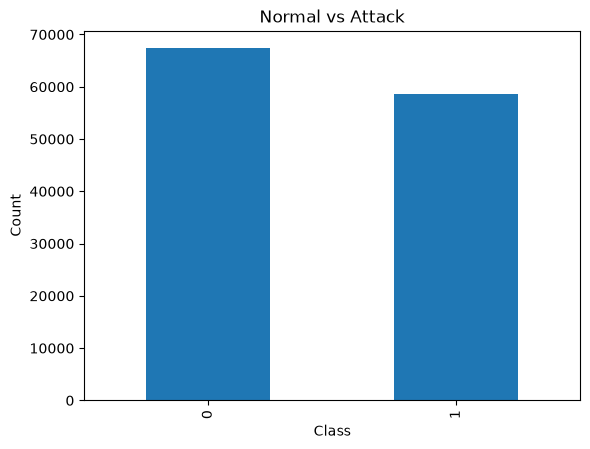

In [21]:
import matplotlib.pyplot as plt

train["binary_label"].value_counts().plot(
    kind="bar",
    xlabel="Class",
    ylabel="Count",
    title="Normal vs Attack"
)

plt.show()

In [23]:
X_train = train.drop(columns=["label", "binary_label"])
y_train = train["binary_label"]

X_test = test.drop(columns=["label", "binary_label"])
y_test = test["binary_label"]


In [27]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns
print(categorical_cols)

Index(['protocol_type', 'service', 'flag'], dtype='str')


/var/folders/4s/c_3w3vw96s53p_ffdszr4f3h0000gn/T/ipykernel_24730/2247251130.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object"]).columns


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols,
        )
    ],
    remainder="passthrough",
)

In [29]:
X_train_processed = preprocessor.fit_transform(X_train)

print(X_train_processed.shape)

(125973, 123)
